## 기본 통계량 및 분포 분석

## 뉴욕 지역별 숙소 특성 및 가격 분포 분석
### 목적 : 뉴욕 어떤 숙소 유형으로 시작하는게 유리할까?
- 지역별 숙소 개수 → 현황같은데.. +시각화 → 여기서 더 추가할 수 있나?
- 지역별 평균 가격 → 지역별로 평균 가격에 차이가 있을 것이다.
- 숙소 유형별 가격 비교 → 숙소 유형에 따라 가격에 차이가 있을 것이다.
- 리뷰나 평점 → 상관계수 .........

---
## 데이터로드

In [80]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [81]:
#필요한 컬럼 37개만 가져오기
df = pd.read_csv("data/2025_Airbnb_NYC_listings.csv", index_col=0)

choice = [
    "id","name","description","host_id","host_since","host_response_time",
    "host_response_rate","host_acceptance_rate","host_is_superhost",
    "neighbourhood_cleansed","neighbourhood_group_cleansed",
    "latitude","longitude","property_type","room_type","accommodates",
    "bedrooms","beds","amenities","price","availability_365",
    "number_of_reviews","number_of_reviews_ltm",
    "estimated_occupancy_l365d","estimated_revenue_l365d",
    "review_scores_rating","review_scores_accuracy","review_scores_cleanliness",
    "review_scores_checkin","review_scores_communication","review_scores_location",
    "review_scores_value",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "reviews_per_month"
]

df_ch = df[choice]
df_ch.head()

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,NaN,NaN,NaN,f,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,NaN,NaN,100%,f,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,within a few hours,100%,40%,f,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,within an hour,100%,97%,t,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,within an hour,100%,100%,t,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",$130.00,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54


In [82]:
df_ch.shape

(22308, 37)

In [83]:
# price "$", "," 제거 -> float형태로 변경
df_ch['price'] = (df_ch['price'].str.replace("$", "").str.replace(",","").astype(float))
df_ch['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
37429     72.0
37430     58.0
37431    299.0
37432    200.0
37433     58.0
Name: price, Length: 22308, dtype: float64

In [84]:
#로그 씌워서 작업해보기 - 경민님 코드
df_ch['log_price'] = np.log1p(df_ch['price'])

q1_log = np.percentile(df_ch['log_price'], 25)
q3_log = np.percentile(df_ch['log_price'], 75)
iqr_log = q3_log - q1_log

lower_log = q1_log - 1.5 * iqr_log
upper_log = q3_log + 1.5 * iqr_log

log_outliers = df_ch.loc[(df_ch['log_price'] > upper_log) | (df_ch['log_price'] < lower_log)]
print(f"로그 변환 후 이상치 개수: {len(log_outliers)}")

# 상한선보다 큰 값만 조회
df_processed_log = df_ch.loc[df_ch['log_price'] > upper_log].copy()
print(f"상한선보다 큰 값만: ", df_processed_log['price'].describe())

# 하한선보다 큰 값만 조회
df_processed_log = df_ch.loc[df_ch['log_price'] < lower_log].copy()
print(f"하한선보다 작은 값만: ", df_processed_log['price'].describe())

# 이상치 제거한 데이터프레임
df_ch_cleaned = df_ch.loc[(df_ch['log_price'].between(lower_log, upper_log))]
print(f"이상치 제거한 것 : ", df_ch_cleaned['price'].describe())

로그 변환 후 이상치 개수: 253
상한선보다 큰 값만:  count      241.000000
mean      2649.759336
std       2947.038941
min       1136.000000
25%       1333.000000
50%       1707.000000
75%       2500.000000
max      20000.000000
Name: price, dtype: float64
하한선보다 작은 값만:  count    12.000000
mean      9.416667
std       2.778434
min       7.000000
25%       8.000000
50%       8.000000
75%      10.000000
max      16.000000
Name: price, dtype: float64
이상치 제거한 것 :  count    22055.000000
mean       187.328542
std        157.662373
min         19.000000
25%         85.000000
50%        139.000000
75%        236.000000
max       1129.000000
Name: price, dtype: float64


In [85]:
# 이상치 제거 후 df_ch로 덮어쓰기
df_ch = df_ch.loc[df_ch['log_price'].between(lower_log, upper_log)].copy()

---
## 숙소 유형별 가격 비교

In [86]:
df_ch.groupby("room_type")["price"].mean()

room_type
Entire home/apt    234.328315
Hotel room         448.086957
Private room       113.837492
Shared room        123.833333
Name: price, dtype: float64

<Axes: title={'center': 'price'}, xlabel='room_type'>

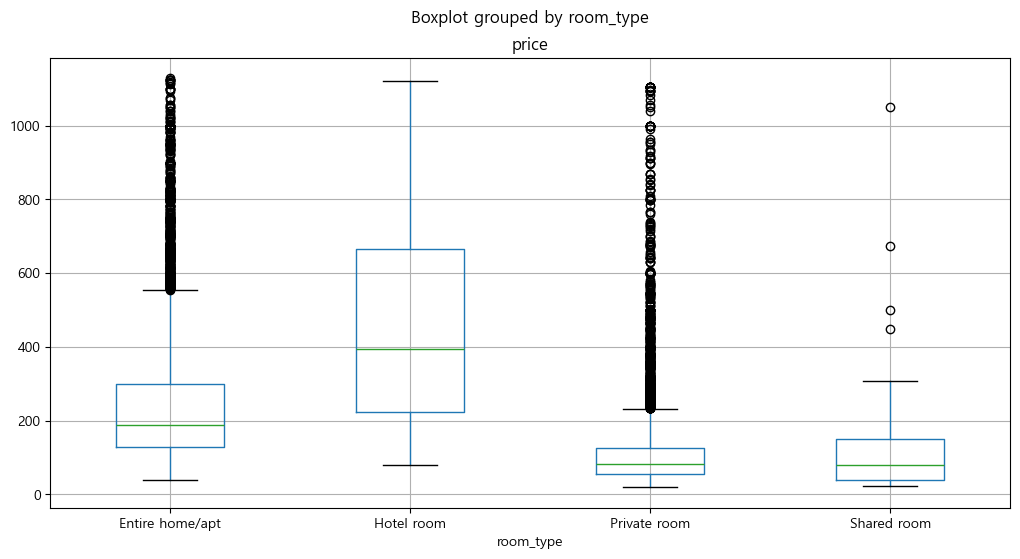

In [87]:
df_ch.boxplot(column="price", by="room_type")

<Axes: title={'center': 'log_price'}, xlabel='room_type'>

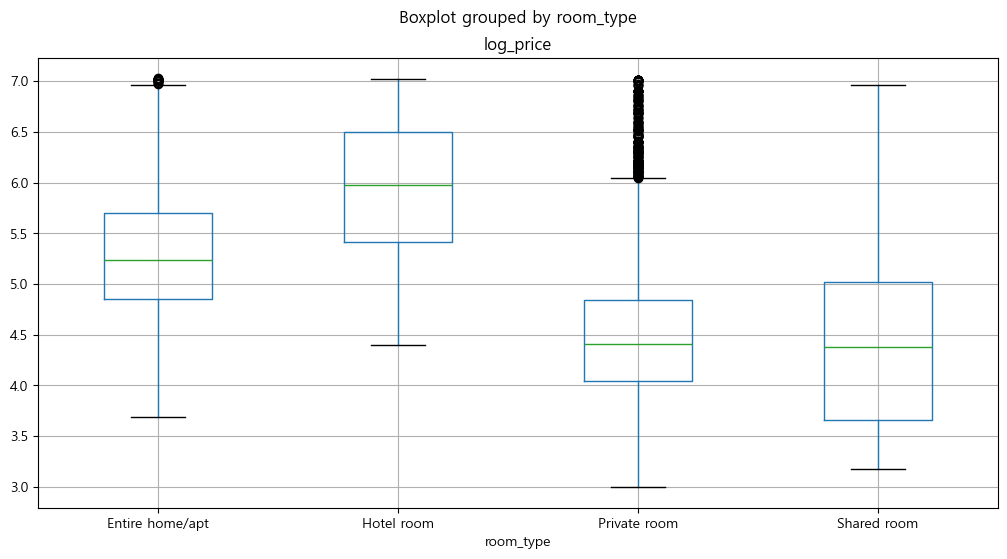

In [88]:
# 가격 log씌워서 boxplot
df_ch.assign(log_price=np.log1p(df_ch["price"])).boxplot(column="log_price", by="room_type")

- Hotel의 중앙값(초록색) 가장 높아 가장 비싼 유형이다.
- Entire home/apt는 그다음으로 중앙값(초록색)이 높다.
- Private room과 Shared room의 중앙값(초록색)은 비슷했다.
- Shared room은 박스가 Private room에 비해 넓어 가격 변동이 조금 더 커 보인다.

## 숙소 유형별 차이가 유의미한가?

### 1. 가설설정
- 귀무가설 : 숙소 유형별로 평균 가격은 같다.
- 대립가설 : 숙소 유형별로 평균 가격이 다르다.

Entire home/apt, Hotel room, Private room, Shared room

In [89]:
df_ch['room_type'].value_counts()

room_type
Entire home/apt    12488
Private room        9138
Hotel room           345
Shared room           84
Name: count, dtype: int64

In [90]:
g1 = df_ch.loc[df['room_type']=='Entire home/apt','price']
g2 = df_ch.loc[df['room_type']=='Private room','price']
g3 = df_ch.loc[df['room_type']=='Hotel room','price']
g4 = df_ch.loc[df['room_type']=='Shared room','price']

### 2. 검정방법 선택
- 후보1: 일원 ANOVA
    - 조건에 맞는지 1)정규성 2)등분산성 3)독립성 

#### 2-1) 정규성 확인하기

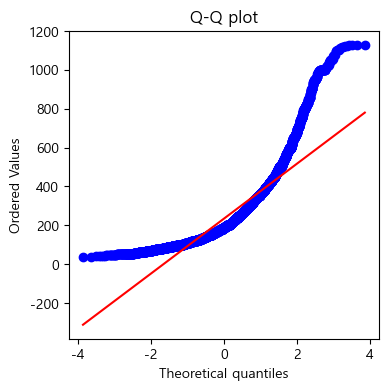

In [91]:
# q-q plot 

plt.figure(figsize=(4,4))
stats.probplot(g1, plot=plt)
plt.title("Q-Q plot")
plt.show()

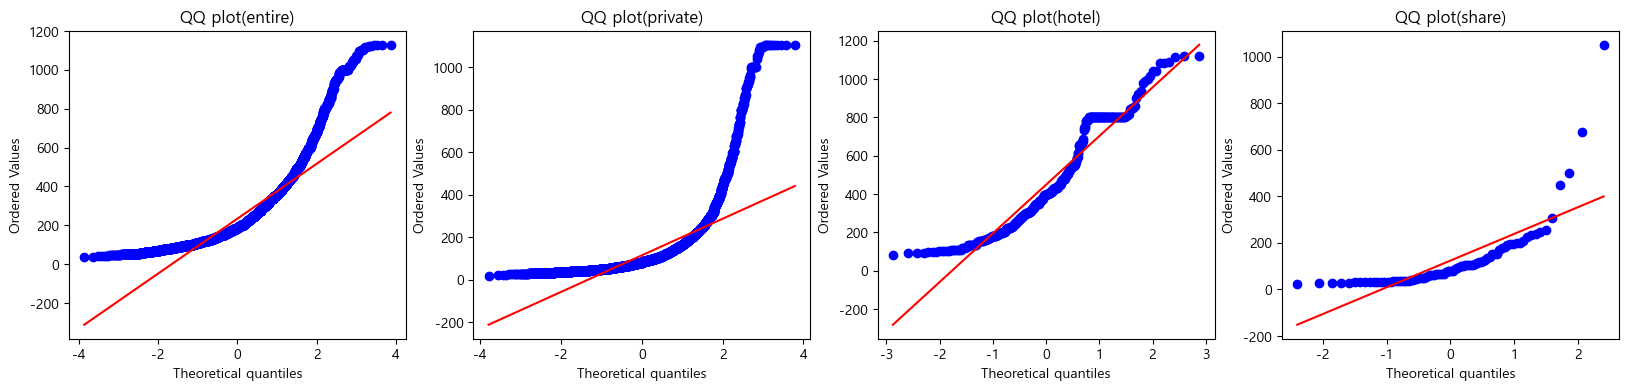

In [92]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(g1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(g2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(g3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(g4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

- 정규성을 만족하지 않음
- 롱테일(오른쪽 꼬리가 긴 형태)

### 3. 유의수준 결정 : 0.05

### 4. 검정 통계량, p-value 계산

In [93]:
stat, p = stats.kruskal(g1, g2, g3, g4)
stat, p

(np.float64(7297.600102011893), np.float64(0.0))

### 5. 결과해석

p-value가 유의수준보다 낮으므로 귀무가설 기각.(p < 0.05)

- 귀무가설 : 숙소 유형별로 평균 가격은 같다.
- 대립가설 : 숙소 유형별로 평균 가격이 다르다.

## 사후검정 (Dunn test)

In [94]:
# Dunn 사후검정 
data = df_ch[['room_type', 'price']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="price",
                        group_col="room_type",
                        p_adjust="holm"
                        )

In [95]:
posthoc

,Entire home/apt,Hotel room,Private room,Shared room
Entire home/apt,1.000000e+00,1.812267e-34,0.000000e+00,2.171568e-24
Hotel room,1.812267e-34,1.000000e+00,6.658707e-238,1.025764e-48
Private room,0.000000e+00,6.658707e-238,1.000000e+00,9.059061e-01
Shared room,2.171568e-24,1.025764e-48,9.059061e-01,1.000000e+00


**해석 : Entire home/apt, Hotel room, Private room, Shared room 평균가격이 모두 서로 다르다 ( 유의 수준 0.05 기준)**